# Исследование рынка заведений общественного питания Москвы

- Автор: Кривенко Виктория 
- Дата: 16.06.2026

### Цели и задачи проекта

**Цель** провести исследовательский анализ рынка общественного питания Москвы для инвесторов из фонда Shut Up and Take My Money

**Задачи**
- Загрузить и ознакомиться с данными;
- Выполнить предобработку данных: устранить пропуски, дубликаты, привести данные к корректным типам;
- Провести исследовательский анализ данных: изучить категории заведений, районы, соотношение сетевых и несетевых заведений, количество посадочны мест, рейтинг, средний чек;
- Сформулировать итоговые выводы и дать рекомендации для инвесторов

### Описание данных

**`rest_info.csv`** - основная информация о заведениях:
- `name` - название заведения
- `address` - адрес
- `district` - административный район Москвы
- `category` - категория (кафе, ресторан, бар и т.д.)
- `hours` - информация о днях и часах работы
- `rating` - рейтинг заведения по оценкам пользователей в Яндекс Картах (макс. 5.0)
- `chain` - сетевое (1) / несетевое (0) заведение
- `seats` - количество посадочных мест

**`rest_price.csv`** - информация о ценах:
- `price` - категория цен
- `avg_bill` - средняя стоимость заказа в виде диапазона
- `middle_avg_bill` - медиана среднего чека (Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт)
- `middle_coffee_cup` - медиана цены чашки капучино (Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт)

### Содержимое проекта
1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных (8 задач)
4. Итоговый вывод и рекомендации
---

## 1. Загрузка данных и знакомство с ними

- Загружаем нужные библиотеки и данные о заведениях общественного питания Москвы.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install phik
from phik import phik_matrix

     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01


In [2]:
# Выгружаем данные из датасетов rest_info.csv и rest_price.csv в датафреймы rest_info и rest_price
rest_info = pd.read_csv('/datasets/rest_info.csv')
rest_price = pd.read_csv('/datasets/rest_price.csv')

- Познакомимся с данными датасета `rest_info.csv` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 8406 строк и 9 столбцов. Данные соответствуют описанию проекта и содержат информацию о заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:

- названия столбцов уже приведены к единому стилю и не требуют переименования;
- типы данных в целом соответствуют содержимому столбцов;
- пропуски присутствуют в столбцах `hours` и `seats`, поэтому необходимо изучить причины их появления и определить способ обработки;
- столбец `chain` содержит бинарный признак (0 и 1), соответственно его тип можно оптимизировать и привести к типу int8;
- столбец `seats` имеет тип `float64`, вероятно, из-за наличия пропусков, хотя количество посадочных мест является целочисленным признаком;
- на этапе предобработки также следует проверить данные на явные и неявные дубликаты.

Познакомимся с данными датасета `rest_price.csv` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [5]:
# Выводим первые строки датафрейма на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 4058 строк и 5 столбцов. Данные соответствуют описанию проекта и содержат информацию о ценах в заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:
- названия столбцов уже приведены к единому стилю;
- во всех столбцах, кроме `id`, присутствуют пропущенные значения, причины которых необходимо изучить на этапе предобработки;
- часть пропусков в `middle_avg_bill` и `middle_coffee_cup` является ожидаемой, так как эти столбцы заполняются только для определённого типа значений из `avg_bill`;
- после анализа и обработки пропусков при необходимости можно будет оптимизировать типы данных числовых столбцов.

### Подготовка единого датафрейма

- Объединим данные двух датасетов в один

In [7]:
# Соединяем данные в единый датафрейм df
df = rest_info.merge(rest_price, on='id', how='left')

# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## 2. Предобработка данных

Подготавливаем данные к исследовательскому анализу:

Изучаем корректность типов данных и при необходимости проводим их преобразование

In [8]:
# Смотрим типы данных
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Оптимизируем тип данных столбца `chain` с помощью понижения разрядности, так как он содержит только бинарные значения (0 и 1). Это позволит уменьшить объём занимаемой памяти без потери информации. 

Остальные числовые столбцы пока не изменяем: `seats`, `middle_avg_bill` и `middle_coffee_cup` содержат пропущенные значения, поэтому после их обработки можно будет привести их к целочисленному типу при необходимости.

In [9]:
# Оптимизируем тип данных столбца chain, выполнив понижение разрядности целочисленного типа
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

# Проверяем тип данных после оптимизации
df['chain'].dtypes

dtype('int8')

- Изучим пропущенные значения в данных: посчитаем их количество в каждом столбце датафрейме, изучим данные с пропущенными значениями и предположим гипотезы их появления.

In [10]:
# Посчитаем количество пропущенных значений
df.isna().sum() 

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

Пропуски обнаружены в следующих столбцах:
- `hours` - вероятно, режим работы не был указан в источнике данных;
- `seats` - количество посадочных мест неизвестно либо отсутствует для некоторых типов заведений;
- `price` и `avg_bill` - информация о стоимости не указана для части заведений;
- `middle_avg_bil` и `middle_coffee_cup` содержат ожидаемые пропуски, так как заполняются только для определённых форматов значений столбца avg_bill, что указано в описании датасета.

In [11]:
# Анализ пропусков в hours
df[df['hours'].isna()]['category'].value_counts()

кафе               375
ресторан            74
быстрое питание     33
бар,паб             18
кофейня             15
столовая             9
булочная             7
пиццерия             5
Name: category, dtype: int64

In [12]:
# Анализ пропусков в seats
df[df['seats'].isna()]['category'].value_counts()

кафе               1160
ресторан            773
кофейня             662
бар,паб             297
быстрое питание     254
пиццерия            206
столовая            151
булочная            108
Name: category, dtype: int64

In [13]:
# Анализ пропусков в price
df[df['price'].isna()]['category'].value_counts()

кафе               1745
ресторан           1026
кофейня             937
быстрое питание     413
пиццерия            322
бар,паб             271
булочная            215
столовая            162
Name: category, dtype: int64

- Пропуски в столбцах `seats` и `price` распределены преимущественно в категориях "кафе", "ресторан" и "кофейня", что указывает на их системный характер и связано с особенностями сбора данных или отсутствием информации в источнике.
- Пропуски в столбце `hours` встречаются значительно реже и также распределены преимущественно среди массовых категорий заведений.

На данном этапе пропуски в данных не были заполнены или удалены:
- пропуски в столбцах `middle_avg_bill` и `middle_coffee_cup` возникают из-за логики их расчёта и являются ожидаемыми.
- в других столбцах (`seats`, `price`, `avg_bill`, `hours`) пропуски, вероятно, связаны с отсутствием информации в источнике данных, поэтому их заполнение на данном этапе может привести к искажению распределений и повлиять на результаты дальнейшего анализа.

В связи с этим пропуски были сохранены для проведения более корректного исследовательского анализа данных.

- Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [14]:
# Проверяем полные дубликаты
df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты - значения по `id` заведений должны быть уникальными, то есть каждая строка в данных - уникальное заведение:

In [15]:
# Проверяем неявные дубликаты
df.duplicated(subset='id').sum()

0

Каждая строка соответствует уникальному заведению общественного питания. Теперь проверим корректность написания категориальных значений:

In [16]:
for column in ['category', 'district', 'name', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце name:
['#КешбэкКафе' '+39 Pizzeria Mozzarella bar' '1 Этаж' ... 'Ясно' 'Яуза'
 'ночной Баку']

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]



- Категории и названия заведений, административные округа и ценовые категории приведены к единому формату и не содержат явных ошибок в написании.

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [17]:
# Создаем столбец
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

#  Выводим первые 5 строк датафрейма
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


---

### Промежуточный вывод


На этапе предобработки были подготовлены данные для дальнейшего исследования. Данные двух датасетов были объединены в единый датафрейм с помощью соединения left join, что позволило сохранить все сведения о заведениях общественного питания.

Была выполнена оптимизация типа данных столбца `chain` путём понижения разрядности. Пропущенные значения были проанализированы и сохранены, так как они в большинстве случаев обусловлены особенностями исходных данных, а их заполнение могло бы привести к искажению результатов исследования. Для столбцов `middle_avg_bill` и `middle_coffee_cup` часть пропусков является ожидаемой согласно описанию датасета.

Проверка показала отсутствие явных и неявных дубликатов, а также явных ошибок в написании категориальных признаков. Для дальнейшего анализа был создан новый логический признак `is_24_7`, отражающий заведения, работающие ежедневно и круглосуточно.

На этапе предобработки строки из датафрейма не удалялись, поэтому объём данных остался неизменным - 8406 записей.

## 3. Исследовательский анализ данных

---

### Задача 1

Исследуем количество объектов общественного питания по каждой категории.

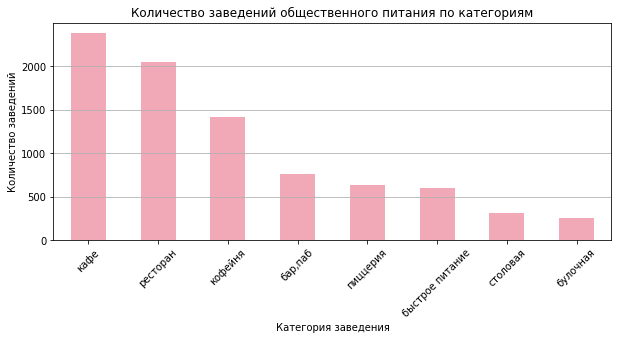

In [18]:
# Строим столбчатую диаграмму
df['category'].value_counts().plot(
    kind='bar',
    title='Количество заведений общественного питания по категориям',
    legend=False,
    ylabel='Количество заведений',
    xlabel='Категория заведения',
    rot=45,
    color='#f1a9b7',
    figsize=(10,4))
plt.grid(axis='y')
plt.show()

In [19]:
df['category'].value_counts()

кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

В результате анализа категорий заведений общественного питания в Москве было выявлено, что наибольшее количество объектов представлено в категориях **"кафе" (2378 заведений)** и **"ресторан" (2043 заведения)**. Также значительную долю составляют **"кофейни" (1413 заведений)**.

Средний сегмент рынка занимают **"бары/пабы" (765 заведений)**, а также **"пиццерии" (633)** и **"заведения быстрого питания" (603)**.

Наименьшее количество объектов наблюдается в категориях **"столовые" (315 заведений)** и **"булочные" (256 заведений)**.

Таким образом, рынок общественного питания Москвы преимущественно представлен кафе, ресторанами и кофейнями, тогда как остальные категории встречаются значительно реже.


---

### Задача 2

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

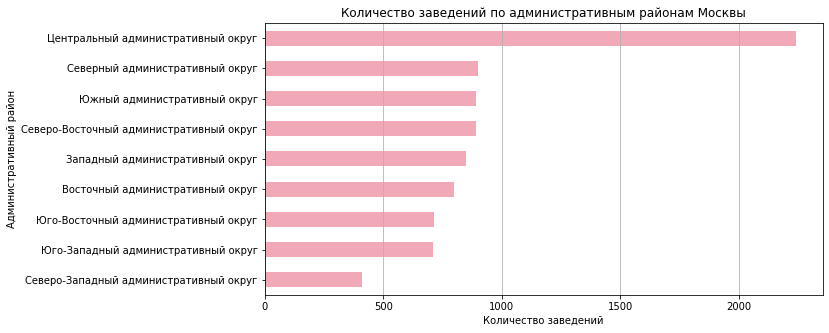

In [20]:
# Строим линейчатую диаграмму для исследования распределения количества заведений по административным районам Москвы
df['district'].value_counts().sort_values().plot(
    kind='barh',
    color='#f1a9b7',
    figsize=(10,5))

plt.ylabel('Административный район')
plt.xlabel('Количество заведений')
plt.title('Количество заведений по административным районам Москвы')
plt.grid(axis='x')
plt.show()

In [21]:
df['district'].value_counts()

Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Наибольшее количество заведений сосредоточено в **Центральном административном округе Москвы (2242 заведения)**. Это говорит одновременно о высокой проходимости и высокой конкуренции. При выборе локации необходимо учитывать, что открытие заведения в центре потребует более выраженного конкурентного преимущества.

**Остальные округа** представлены значительно равномернее - в среднем от **700 до 900 заведений**.

Наименьшее количество заведений наблюдается в **Северо-Западном административном округе (409 заведений)**.

- Исследуем распределение категорий заведений в ЦАО

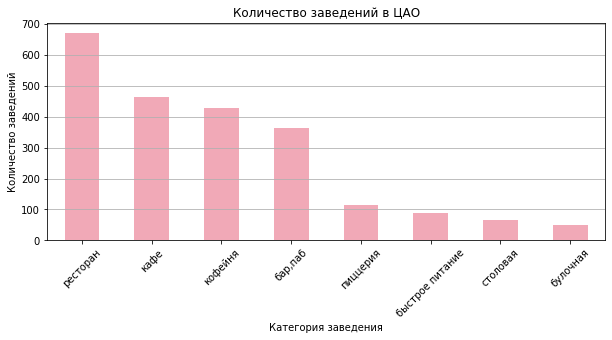

In [22]:
# фильтруем ЦАО
central_df = df[df['district'] == 'Центральный административный округ']

# Строим столбчатую диаграмму
central_df['category'].value_counts().plot(
    kind='bar',
    title='Количество заведений в ЦАО',
    legend=False,
    ylabel='Количество заведений',
    xlabel='Категория заведения',
    rot=45,
    color='#f1a9b7',
    figsize=(10,4))
plt.grid(axis='y')
plt.show()

In [23]:
central_df['category'].value_counts()

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

В Центральном административном округе Москвы наибольшее количество заведений представлено **ресторанами (670)**, **кафе (464)** и **кофейнями (428)**.

Следующей по распространённости категорией являются **бары и пабы (364 заведения)**.

Значительно меньше в ЦАО представлены **пиццерии (113)**, **заведения быстрого питания (87)**, **столовые (66)** и **булочные (50)**.

Таким образом, в Центральном административном округе основную часть рынка общественного питания составляют рестораны, кафе, кофейни и бары, тогда как пиццерии, заведения быстрого питания, столовые и булочные встречаются значительно реже.

---

### Задача 3

Изучаем соотношение сетевых и несетевых заведений в целом по всем данным.

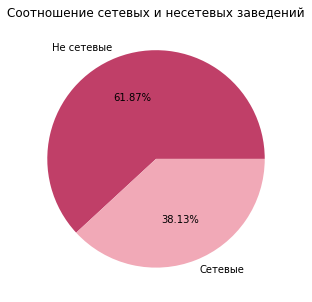

In [24]:
# Строим круговую диаграмму соотношения сетевых и несетевых заведений
df['chain'].value_counts().plot(
    kind='pie',
    labels=['Не сетевые', 'Сетевые'],
    autopct='%1.2f%%',
    colors=['#c03f68', '#f1a9b7'],
    figsize=(5, 5),
    ylabel=''
)

plt.title('Соотношение сетевых и несетевых заведений')
plt.show()

In [25]:
df['chain'].value_counts()

0    5201
1    3205
Name: chain, dtype: int64

Среди всех заведений общественного питания Москвы **5201 заведение (61,87%)** являются несетевыми, а **3205 заведений (38,13%)** относятся к сетевым. Таким образом, в целом по рынку преобладают несетевые заведения.

- Рассмотрим какие категории заведений чаще являются сетевыми:

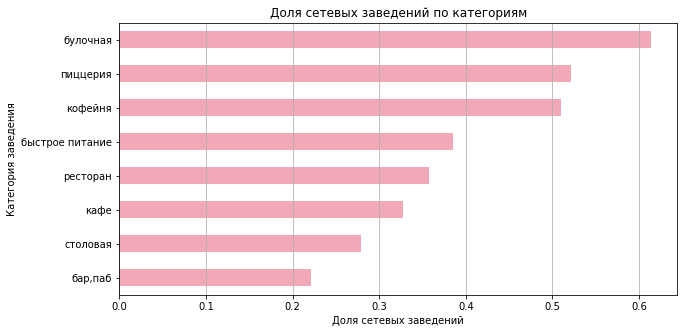

In [26]:
# Строим столбчатую диаграмму
df.groupby('category')['chain'].mean().sort_values().plot(
    kind = 'barh',
    figsize = (10,5),
    color='#f1a9b7',
    title='Доля сетевых заведений по категориям')

plt.xlabel('Доля сетевых заведений')
plt.ylabel('Категория заведения')
plt.grid(axis='x')
plt.show()

In [27]:
df.groupby('category')['chain'].mean().sort_values().round(2)

category
бар,паб            0.22
столовая           0.28
кафе               0.33
ресторан           0.36
быстрое питание    0.38
кофейня            0.51
пиццерия           0.52
булочная           0.61
Name: chain, dtype: float64

**Наибольшая доля сетевых заведений** наблюдается в булочных (61%), пиццериях (52%) и кофейнях (51%). В этих категориях сетевые заведения составляют около половины или более от общего числа.

В категориях заведений быстрого питания (38%), ресторанов (36%), кафе (33%), столовых (28%) и особенно баров/пабов (22%) **доля сетевых заведений ниже**, и в них чаще представлены несетевые форматы.

---

### Задача 4

Исследуем количество посадочных мест в заведениях. 

Для начала изучим распределение количества посадочных мест в заведениях общественного питания Москвы. Это позволит оценить, какое количество мест встречается чаще всего, а также определить наличие возможных выбросов и аномальных значений.

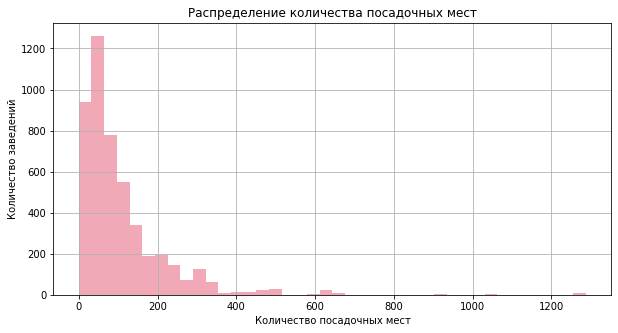

In [28]:
# Строим гистограмму распределения количества посадочных мест
df['seats'].hist(
    bins=40,
    color='#f1a9b7',
    figsize=(10, 5))

# Добавляем подписи к осям и заголовок
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Количество заведений')

plt.show()

Распределение количества посадочных мест имеет правостороннюю асимметрию. Большинство заведений располагает сравнительно небольшим количеством посадочных мест - чаще всего до 100 мест. По мере увеличения количества мест число заведений постепенно уменьшается. При этом встречается небольшое количество заведений с очень большим числом посадочных мест, что формирует длинный правый хвост распределения.

- Для поиска выбросов построим диаграмму размаха.

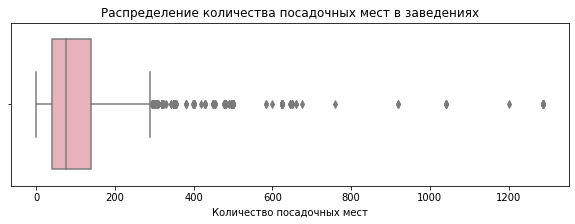

In [29]:
# Строим диаграмму размаха для количества посадочных мест
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df['seats'],
    color='#f1a9b7')

# Добавляем заголовок и подпись оси
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')

plt.show()

In [30]:
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Диаграмма размаха показывает наличие большого количества выбросов в правой части распределения. Основная масса заведений имеет от 40 до 140 посадочных мест, медианное значение составляет 75 мест. При этом встречаются заведения с несколькими сотнями и даже более чем тысячей посадочных мест (максимальное значение - 1288). Вероятно, такие значения относятся к крупным ресторанам, банкетным залам, столовым, фуд-кортам или другим заведениям, рассчитанным на обслуживание большого количества посетителей одновременно. Такие значения являются редкими и существенно отличаются от основной массы наблюдений.

Наличие выбросов не свидетельствует об ошибках в данных, поэтому удалять их на данном этапе нецелесообразно.

- Для каждой категории заведений определим наиболее типичное количество посадочных мест. Поскольку в данных присутствуют аномально большие значения (выбросы), в качестве наиболее типичного значения будем использовать медиану.

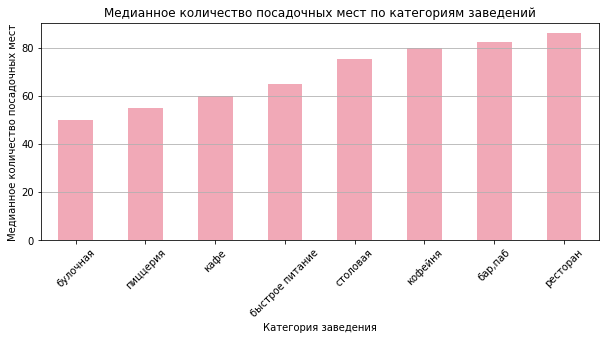

In [31]:
# Строим столбчатую диаграмму медианного количества посадочных мест по категориям
df.groupby('category')['seats'].median().sort_values().plot(
    kind='bar',
    color='#f1a9b7',
    figsize=(10, 4),
    title = 'Медианное количество посадочных мест по категориям заведений',
    xlabel= 'Категория заведения',
    ylabel = 'Медианное количество посадочных мест',
    rot = 45)

plt.grid(axis='y')
plt.show()

In [32]:
df.groupby('category')['seats'].median()

category
бар,паб            82.5
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           75.5
Name: seats, dtype: float64

Наиболее типичное количество посадочных мест различается в зависимости от категории заведения:  

- Наименьшая медиана наблюдается у булочных (50 мест), пиццерий (55 мест), кафе (60 мест) и заведений быстрого питания (65 мест).
- В ресторанах, барах/пабах, кофейнях и столовых медианное количество посадочных мест выше и составляет от 75 до 86 мест. 

---

### Задача 5

Исследуем рейтинг заведений. 

Предварительно изучим статистику по столбцу рейтинг для проверки на выбросы

In [33]:
df['rating'].describe()

count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

Аномальных значений или явных выбросов в распределении рейтинга не наблюдается, поэтому данные можно использовать для дальнейшего анализа без дополнительной обработки.

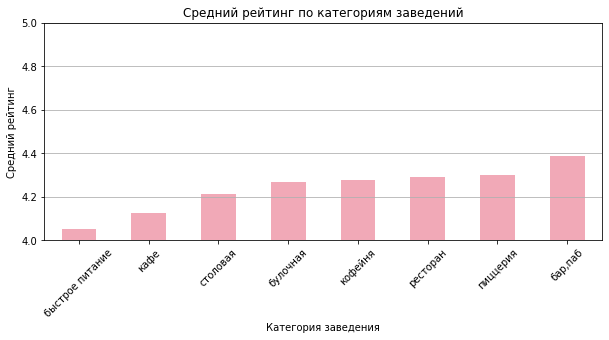

In [34]:
# Строим столбчатую диаграмму среднего рейтинга заведений по категориям

df.groupby('category')['rating'].mean().sort_values().plot(
    kind='bar',
    color='#f1a9b7',
    figsize=(10, 4),
    title='Средний рейтинг по категориям заведений',
    xlabel='Категория заведения',
    ylabel='Средний рейтинг',
    rot=45
)
plt.ylim(4, 5)
plt.grid(axis='y')

plt.show()

In [35]:
df.groupby('category')['rating'].mean().sort_values()

category
быстрое питание    4.050249
кафе               4.123886
столовая           4.211429
булочная           4.268359
кофейня            4.277282
ресторан           4.290357
пиццерия           4.301264
бар,паб            4.387712
Name: rating, dtype: float64

Средний рейтинг заведений по категориям варьируется незначительно и находится в диапазоне примерно от **4.05 до 4.39 балла**:

- **Наименьший средний рейтинг** наблюдается у заведений быстрого питания (4.05), далее следуют кафе (4.12) и столовые (4.21). 
Более высокие значения характерны для булочных (4.27), кофеен (4.28), ресторанов (4.29) и пиццерий (4.30). 
- **Наибольший средний рейтинг** имеют бары и пабы (4.39).

---

### Задача 6

Визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным.

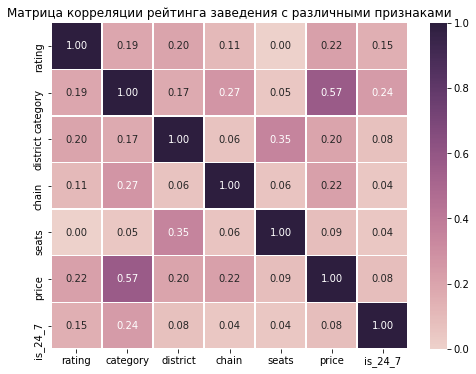

In [36]:
# Исследуем корреляцию рейтинга заведения с различными признаками

# Выбираем необходимые столбцы
corr_columns = [
    'rating',
    'category',
    'district',
    'chain',
    'seats',
    'price',
    'is_24_7'
]

# Рассчитываем матрицу корреляции
corr_matrix = df[corr_columns].phik_matrix(
    interval_cols=['rating', 'seats']
)

# Строим тепловую карту матрицы корреляции
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cmap=sns.cubehelix_palette(as_cmap=True)
)

# Добавляем заголовок
plt.title('Матрица корреляции рейтинга заведения с различными признаками')

plt.show()

Наибольшая связь рейтинга наблюдается с ценовой категорией заведения (0.22). Однако значение коэффициента остаётся низким, что свидетельствует о слабой зависимости между рейтингом и ценовой категорией. 

Остальные признаки также демонстрируют слабую или практически отсутствующую связь с рейтингом заведения.

- Проверим более подробно связь между рейтингом заведения и его ценовой категорией. Для этого рассчитаем средний рейтинг для каждой ценовой категории.

In [37]:
# Рассчитываем средний рейтинг по ценовым категориям
df.groupby('price')['rating'].mean().sort_values().reset_index()

,price,rating
0,низкие,4.173077
1,средние,4.297874
2,выше среднего,4.386348
3,высокие,4.436611


По мере увеличения ценовой категории средний рейтинг заведений также увеличивается. Однако различия между категориями невелики (от 4,17 до 4,44 балла), что соответствует ранее рассчитанному коэффициенту (0.22) и свидетельствует лишь о слабой положительной связи между ценовой категорией и рейтингом заведения.

---

### Задача 7

 

Сгруппируем данные по названиям заведений и выведем топ-15 популярных сетей в Москве: 

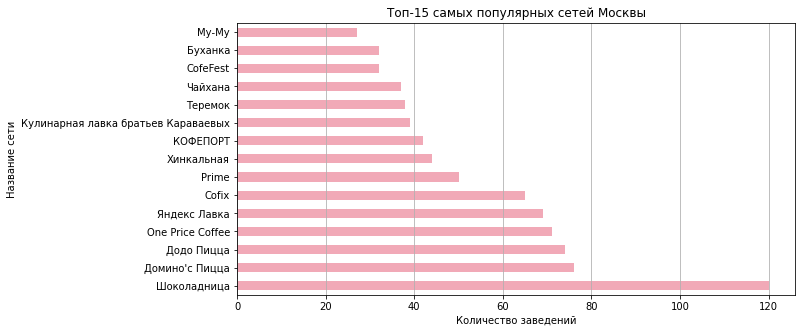

In [38]:
# Cчитаем количество заведений по сети
top15 = df[df['chain'] == 1].groupby('name').size().sort_values(ascending=False).head(15)

# Строим горизонтальную столбчатую диаграмму
top15.plot(
    kind='barh',
    color='#f1a9b7',
    figsize=(10, 5))

plt.title('Топ-15 самых популярных сетей Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.grid(axis='x')

plt.show()

In [39]:
top15

name
Шоколадница                            120
Домино'с Пицца                          76
Додо Пицца                              74
One Price Coffee                        71
Яндекс Лавка                            69
Cofix                                   65
Prime                                   50
Хинкальная                              44
КОФЕПОРТ                                42
Кулинарная лавка братьев Караваевых     39
Теремок                                 38
Чайхана                                 37
CofeFest                                32
Буханка                                 32
Му-Му                                   27
dtype: int64

В ходе анализа были определены 15 наиболее популярных сетей заведений Москвы по количеству объектов. 

Лидером является "Шоколадница" (120 заведений), далее идут "Домино'с Пицца" (76), "Додо Пицца" (74), "One Price Coffee" (71) и "Cofix" (65), что отражает высокую распространённость сетевых форматов быстрого обслуживания и кофеен в городе.

- Для 15 самых популярных сетей рассчитаем средний рейтинг заведений и сравним его с помощью горизонтальной столбчатой диаграммы. Это позволит определить, отличаются ли наиболее распространённые сети по оценкам посетителей:

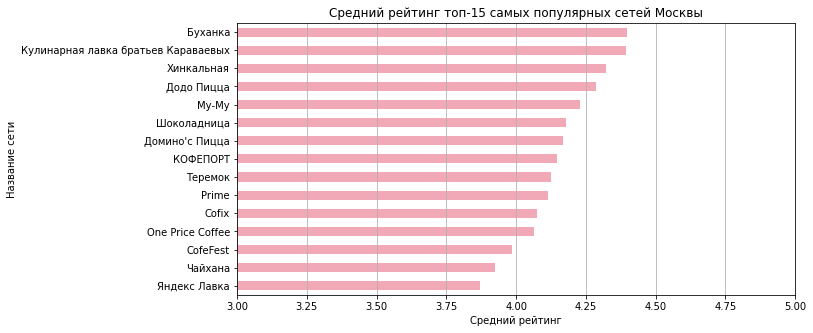

In [40]:
# Рассчитываем средний рейтинг для топ-15 самых популярных сетей
top15_rating = df[df['name'].isin(top15.index)].groupby('name')['rating'].mean().sort_values()

# Строим горизонтальную столбчатую диаграмму среднего рейтинга                               
top15_rating.plot(
    kind='barh',
    color='#f1a9b7',
    figsize=(10, 5))
                
plt.title('Средний рейтинг топ-15 самых популярных сетей Москвы')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.grid(axis='x')

plt.xlim(3, 5)
plt.show()

In [41]:
top15_rating.round(2)

name
Яндекс Лавка                           3.87
Чайхана                                3.92
CofeFest                               3.98
One Price Coffee                       4.06
Cofix                                  4.08
Prime                                  4.12
Теремок                                4.12
КОФЕПОРТ                               4.15
Домино'с Пицца                         4.17
Шоколадница                            4.18
Му-Му                                  4.23
Додо Пицца                             4.29
Хинкальная                             4.32
Кулинарная лавка братьев Караваевых    4.39
Буханка                                4.40
Name: rating, dtype: float64

Анализ среднего рейтинга показал, что значения для большинства сетей находятся в узком диапазоне примерно от **3.87 до 4.4 балла**:
- **Наименьший средний рейтинг** наблюдается у сети "Яндекс Лавка" (3.87), а также у "Чайханы" (3.92) и "CofeFest" (3.98).
- **Наиболее высокие оценки** получили "Буханка" (4.40), "Кулинарная лавка братьев Караваевых" (4.39) и "Хинкальная" (4.32).

- Определим, к каким категориям относятся 15 самых популярных сетей Москвы:

In [42]:
top15_category = df[df['name'].isin(top15.index)].groupby('name')['category'].first().reset_index()
top15_category

,name,category
0,CofeFest,кофейня
1,Cofix,кофейня
2,One Price Coffee,кофейня
3,Prime,ресторан
4,Буханка,булочная
5,Додо Пицца,пиццерия
6,Домино'с Пицца,пиццерия
7,КОФЕПОРТ,кофейня
8,Кулинарная лавка братьев Караваевых,кафе
9,Му-Му,кафе


По категориям заведений топ-15 сетей в основном представлены кофейнями, кафе и пиццериями. То есть самые популярные сети - это заведения повседневного формата, куда люди чаще всего ходят регулярно. Также среди них встречаются рестораны, булочные и точки быстрого питания.

Отдельно стоит отметить сеть "Яндекс Лавка": в исходных данных она классифицируется как ресторан. Это может быть связано с ошибкой при присвоении категории, так как фактически данная сеть относится к сервису доставки и на Яндекс Картах помечается как даркстор, а не как классический ресторан.

---

### Задача 8

Для анализа вариации среднего чека по районам рассчитаем медианное значение показателя `middle_avg_bill` и визуализируем его распределение.

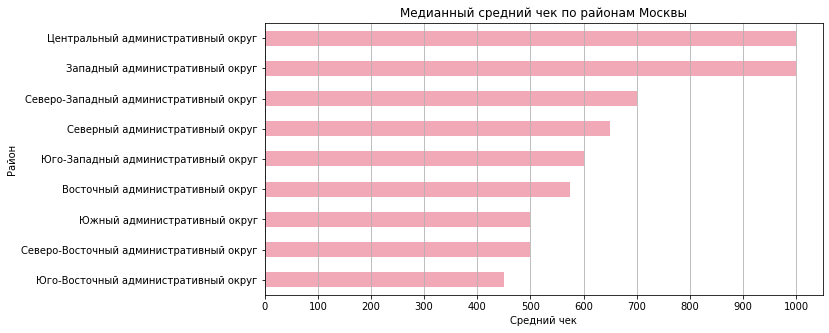

In [43]:
dis_median = df.groupby('district')['middle_avg_bill'].median().sort_values()
dis_median.plot(kind='barh',
              color='#f1a9b7',
              figsize=(10, 5))

plt.title('Медианный средний чек по районам Москвы')
plt.xlabel('Средний чек')
plt.ylabel('Район')
plt.grid(axis ='x')
plt.xticks([0,100,200,300,400,500,600,700,800,900,1000])
plt.show()

In [44]:
dis_median

district
Юго-Восточный административный округ        450.0
Северо-Восточный административный округ     500.0
Южный административный округ                500.0
Восточный административный округ            575.0
Юго-Западный административный округ         600.0
Северный административный округ             650.0
Северо-Западный административный округ      700.0
Западный административный округ            1000.0
Центральный административный округ         1000.0
Name: middle_avg_bill, dtype: float64

Анализ медианного среднего чека по районам Москвы показывает заметную разницу в уровне цен. По мере приближения к центру города средний чек постепенно увеличивается:  
- Наименьшие значения наблюдаются в Юго-Восточном (450 руб.), Северо-Восточном и Южном административных округах (500 руб.)
- В Западном и Центральном административных округах он достигает максимальных значений (1000 руб.).

Можно сделать вывод, что удалённость от центра в целом влияет на уровень цен: в центральных районах заведения дороже, чем в более отдалённых округах.

- Проанализируем цены в Центральном административном округе и других:

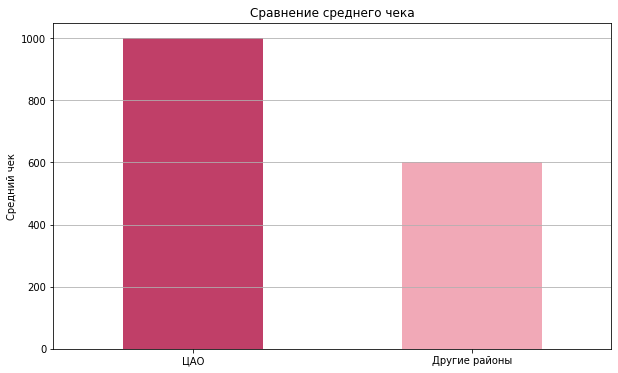

In [45]:
# Считаем медиану среднего чека для ЦАО
cao = df.loc[df['district'] == 'Центральный административный округ','middle_avg_bill'].median()

# Считаем медиану среднего чека для других районов
other = df.loc[df['district'] != 'Центральный административный округ','middle_avg_bill'].median()

# Создаем датафрейм
cao_other = pd.DataFrame({
    'Район': ['ЦАО', 'Другие районы'],
    'Средний чек': [cao, other]})

# Создаем столбчатую диаграмму
cao_other.plot(
    kind = 'bar',
    x = 'Район',
    y = 'Средний чек',
    color = ['#c03f68', '#f1a9b7'],
    figsize = (10, 6),
    legend = False,
    rot = 0)

plt.title('Сравнение среднего чека')
plt.xlabel('')
plt.ylabel('Средний чек')
plt.grid(axis='y')

plt.show()

Сравнение медианного среднего чека показывает заметную разницу между Центральным административным округом и другими районами Москвы.

В ЦАО медианный средний чек составляет около **1000 рублей**, тогда как в остальных районах - примерно **600 рублей**.

Таким образом, заведения в центре Москвы в среднем имеют более высокий уровень цен по сравнению с другими округами, что может быть связано с более высокой стоимостью аренды и ориентацией на более платёжеспособную аудиторию.

---

### Промежуточный вывод

В ходе исследовательского анализа были изучены основные характеристики заведений общественного питания Москвы: категории заведений, сетевой статус, количество посадочных мест, рейтинги, средний чек, а также их зависимость от района города.

Анализ показал, что среди заведений преобладают кафе и рестораны, при этом большинство заведений не относится к сетевым. Для большинства категорий характерно преобладание несетевых заведений, однако среди кофеен и пиццерий доля сетевых объектов сопоставима с долей несетевых.

Распределение количества посадочных мест имеет правостороннюю асимметрию и содержит выбросы, поэтому наиболее типичным показателем является медиана. Наибольшее число посадочных мест характерно для ресторанов, баров и столовых, тогда как булочные, кафе и пиццерии обычно рассчитаны на меньшее количество посетителей.

Средний рейтинг заведений практически не зависит от категории и остаётся высоким для всех типов заведений (около 4–4,4 балла). Наиболее заметная, хотя и слабая, связь рейтинга наблюдается с ценовой категорией: более дорогие заведения в среднем имеют немного более высокий рейтинг.

Среди сетевых заведений наиболее распространены кофейни, кафе и пиццерии. Анализ среднего чека показал, что уровень цен различается по районам Москвы: самые высокие значения наблюдаются в Центральном административном округе, а по мере удаления от центра медианный средний чек в целом снижается.

## 4. Итоговый вывод и рекомендации

### Общий обзор проделанной работы

В ходе исследования был проведён исследовательский анализ рынка заведений общественного питания Москвы. Данные были объединены в один датасет, выполнена предобработка, изучены категории заведений, сетевой статус, количество посадочных мест, рейтинги, ценовые категории и средний чек. Также были проанализированы наиболее популярные сети и особенности распределения цен по административным округам Москвы.


### Основные выводы

Рынок общественного питания Москвы в основном представлен заведениями повседневного формата: кафе (2378 заведений), рестораны (2043) и кофейни (1413). Эти категории формируют основную часть рынка и активно развиваются в сетевом сегменте.

Анализ сетевизации показал, что наибольшая доля сетевых заведений наблюдается в булочных (61%), пиццериях (52%) и кофейнях (51%), тогда как в барах и пабах этот показатель минимален (22%).

Средний рейтинг заведений находится в узком диапазоне от 3.87 до 4.40 балла, при этом большинство категорий имеют значения выше 4.0, что указывает на высокую конкуренцию и общий высокий уровень качества на рынке.

Анализ среднего чека показал выраженную зависимость от расположения: в Центральном административном округе медианный чек составляет около 1000 ₽, тогда как в других районах - около 600 ₽.

Также были выявлены наиболее популярные сетевые заведения. Лидерами по количеству точек являются "Шоколадница" (120), "Домино'с Пицца" (76), "Додо Пицца" (74), "One Price Coffee" (71) и "Cofix" (65), что отражает высокий спрос на массовые форматы кофеен и заведений быстрого питания.


### Рекомендации

При выборе локации в Центральном административном округе следует ориентироваться на более высокий ценовой сегмент, так как медианный средний чек здесь составляет около 1000 ₽, что значительно выше, чем в других районах (~ 600 ₽). Это позволяет рассчитывать на аудиторию с более высокой платёжеспособностью, однако необходимо учитывать и высокий уровень конкуренции в центре города.

С учётом структуры рынка наиболее перспективными форматами остаются кафе, кофейни и пиццерии, так как именно они являются наиболее распространёнными и уже активно представлены среди популярных сетей.

В условиях высокой конкуренции (средний рейтинг большинства заведений выше 4.0) новому заведению важно выделяться не только ценой и качеством обслуживания, но и концепцией, форматом и локацией.